In [1]:
import qutip as qt
from qutip import tensor, basis
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.optimize import curve_fit
from itertools import product
from quantum_logical.trotterization import Trotterization

In [2]:
# creating gates
from quantum_logical.gate_extender import Gate_extender, Convert_levels
dim = 2
N = 5
# creating the set of cnots (this will operate between the g and e levels)
cnot1 = qt.cnot(N=5, control=0, target=1)
cnot2 = qt.cnot(N=5, control=0, target=2)

cnot3 = qt.cnot(N=5, control=0, target=3)
cnot4 = qt.cnot(N=5, control=1, target=3)
 
cnot5 = qt.cnot(N=5, control=1, target=4)
cnot6 = qt.cnot(N=5, control=2, target=4)

# the x_gate needs to be made in a qutrit gate and will involve conversion 
x_gate = qt.Qobj([[0, 1],[1, 0]])
# z_gate = 1/np.sqrt(3) * qt.Qobj([[1, 0, 0],[0, 1, 0], [0, 0, -1]])

# hadamard gate
# hada = 1/np.sqrt(3) * qt.Qobj([[-1/2 + np.sqrt(3)*1j/2, 1, -1/2 - np.sqrt(3)*1j/2], [1, 1, 1], [-1/2 - np.sqrt(3)*1j/2, 1, -1/2 + np.sqrt(3)*1j/2]])
hada = 1/np.sqrt(3) * qt.Qobj([[1, 1, 1],[1, -1/2 + np.sqrt(3)*1j/2, -1/2 - np.sqrt(3)*1j/2], [1, -1/2 - np.sqrt(3)*1j/2, -1/2 + np.sqrt(3)*1j/2]])


# new set of qutrit gates 
# extension of the gates into the qutrit space 
# need to make the gate extender take the individual qudit counts at every instance 
gate_extention = Gate_extender(num_qubits=1)
x_gate, new_dim = gate_extention.qubit_to_qudit(gate=x_gate, from_dim=dim, to_dim=3)
gate_extention = Gate_extender(num_qubits=N)
cnot1, new_dim = gate_extention.qubit_to_qudit(gate=cnot1, from_dim=dim, to_dim=3)
cnot2, new_dim = gate_extention.qubit_to_qudit(gate=cnot2, from_dim=dim, to_dim=3)
cnot3, new_dim = gate_extention.qubit_to_qudit(gate=cnot3, from_dim=dim, to_dim=3)
cnot4, new_dim = gate_extention.qubit_to_qudit(gate=cnot4, from_dim=dim, to_dim=3)
cnot5, new_dim = gate_extention.qubit_to_qudit(gate=cnot5, from_dim=dim, to_dim=3)
cnot6, new_dim = gate_extention.qubit_to_qudit(gate=cnot6, from_dim=dim, to_dim=3)

# conversion of some of the gates into the qutrit space 
converter = Convert_levels(num_qubits=1)
x_gate = converter.level_conversion(levels=[0,2], dim=new_dim, gate=x_gate)
converter = Convert_levels(num_qubits=N)
cnot1= converter.level_conversion(levels=[1,2], dim=new_dim, gate=cnot1)
cnot2= converter.level_conversion(levels=[1,2], dim=new_dim, gate=cnot2)

x_layer = tensor(tensor([x_gate] * 3), tensor([qt.qeye(new_dim)] * 2))
hada_layer = tensor(tensor([hada] * 3), tensor([qt.qeye(new_dim)] * 2))

C:\Users\girgi\AppData\Local\Temp\ipykernel_27376\476993609.py:6: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  cnot1 = qt.cnot(N=5, control=0, target=1)
C:\Users\girgi\AppData\Local\Temp\ipykernel_27376\476993609.py:7: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  cnot2 = qt.cnot(N=5, control=0, target=2)
C:\Users\girgi\AppData\Local\Temp\ipykernel_27376\476993609.py:9: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
fr

In [3]:
hada_layer * hada_layer == tensor([qt.qeye(new_dim)] * N)

False

In [4]:
# building the expectation value calculator 
basis0 = qt.Qobj([[1],[0],[0]])
basis1 = qt.Qobj([[0],[1],[0]])
basis2 = qt.Qobj([[0],[0],[1]])
vector0 = hada * basis0
vector1 = hada * basis1
vector2 = hada * basis2
vectors = [vector0, vector1, vector2]
vectors = [tensor(i,j,k) for i in vectors for j in vectors for k in vectors]

In [5]:
# create fidelity function
# add others if you want another metric 
def hilbert_schmidt_fid_func(rho, sigma):
    return np.abs((sigma * rho).tr()) / np.sqrt((rho * rho).tr() * (sigma * sigma).tr())

x_gate

Quantum object: dims = [[3], [3]], shape = (3, 3), type = oper, isherm = True
Qobj data =
[[1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]]

In [6]:
# not satisfied with the correction there has to be more that can be done because right now this is not good 
# do the whole thing with some decayed state out and see what the result should be 
# what should the correction z operator do 
correction_z = qt.Qobj([[1, 0],[0, -1]])
gate_extention = Gate_extender(num_qubits=1)
correction_z, new_dim = gate_extention.qubit_to_qudit(gate=correction_z, from_dim=dim, to_dim=3)
converter = Convert_levels(num_qubits=1)
correction_z = converter.level_conversion(levels=[1,2], dim=new_dim, gate=correction_z)

In [7]:
correction_z

Quantum object: dims = [[3], [3]], shape = (3, 3), type = oper, isherm = True
Qobj data =
[[ 1.  0.  0.]
 [ 0.  1.  0.]
 [ 0.  0. -1.]]

In [8]:
# generating parameters and creating initial state
T1 = 80
T2 = 80

dim = new_dim
trotter_dt = .001

# initializing Trotterization
trotter = Trotterization(trotter_dt=trotter_dt, T1=T1, T2=T2, dim=dim, num_qubits=N, qudit="qutrit")

In [9]:
# creating initial state
# state controls 
alpha = 0
beta = 1

# state
psi0 = tensor((alpha * basis(dim, 0) + beta * basis(dim, 2)).unit(), tensor([basis(dim, 0)] * (N-1)))
# psi0 = tensor(tensor([basis(dim, 2)] * 2), tensor([basis(dim, 0)] * 3)) # used as a sanity check on the ideal setup to test the created gates
rho0 = psi0 * psi0.dag()
rho_encoded = hada_layer * cnot2 * cnot1 * rho0 * cnot1.dag() * cnot2.dag() * hada_layer.dag()
rho_comp = cnot2 * cnot1 * rho0 * cnot1.dag() * cnot2.dag()
rho_encoded_traced = qt.ptrace(rho_encoded, [0,1,2]) 
rho_comp = qt.ptrace(rho_comp, [0,1,2])
# rho_comp
rho_encoded_traced # density matrix print confirmation
# qt.ptrace(rho0, [0,1,2])

Quantum object: dims = [[3, 3, 3], [3, 3, 3]], shape = (27, 27), type = oper, isherm = True
Qobj data =
[[ 0.03703704+0.j         -0.01851852+0.03207501j -0.01851852-0.03207501j
  -0.01851852+0.03207501j -0.01851852-0.03207501j  0.03703704+0.j
  -0.01851852-0.03207501j  0.03703704+0.j         -0.01851852+0.03207501j
  -0.01851852+0.03207501j -0.01851852-0.03207501j  0.03703704+0.j
  -0.01851852-0.03207501j  0.03703704+0.j         -0.01851852+0.03207501j
   0.03703704+0.j         -0.01851852+0.03207501j -0.01851852-0.03207501j
  -0.01851852-0.03207501j  0.03703704+0.j         -0.01851852+0.03207501j
   0.03703704+0.j         -0.01851852+0.03207501j -0.01851852-0.03207501j
  -0.01851852+0.03207501j -0.01851852-0.03207501j  0.03703704+0.j        ]
 [-0.01851852-0.03207501j  0.03703704+0.j         -0.01851852+0.03207501j
   0.03703704+0.j         -0.01851852+0.03207501j -0.01851852-0.03207501j
  -0.01851852+0.03207501j -0.01851852-0.03207501j  0.03703704+0.j
   0.03703704+0.j         -0.01

In [10]:
expectation_values = []
new_vals = []
for vec in vectors:
    val = (vec.dag() * rho_encoded_traced * vec)[0][0][0]
    new_vals.append(val)
expectation_values.append(new_vals)
states = []
states.append(rho_encoded)

In [11]:
# this tells me that all the values are in the 2,2,2 basis

In [12]:
# states = []
fids = []
delay_duration = 2
delay_states = trotter.apply(rho=rho_encoded, duration=delay_duration, unitary=[tensor([qt.qeye(new_dim)] * N)])
states.extend(delay_states)

In [13]:
# qt.ptrace(delay_states[-1], [0,1,2])

In [14]:
for i in range(len(delay_states)):
    new_val = []
    for vec in vectors:
        val = (vec.dag() * qt.ptrace(delay_states[i], [0,1,2]) * vec)[0][0][0]
        new_val.append(val)
    expectation_values.append(new_val)

In [15]:
expectation_values[-1]

[(1.0843084449794261e-08+0j),
 (1.084288058760048e-08+0j),
 (4.878467328416722e-06+0j),
 (1.0842880458745497e-08+0j),
 (1.084282515233922e-08+0j),
 (4.8784673282169396e-06+0j),
 (4.878467328714438e-06+0j),
 (4.8784673287164866e-06+0j),
 (0.002194346479222874+0j),
 (1.0842880835711273e-08+0j),
 (1.0842824976403787e-08+0j),
 (4.878467328531603e-06+0j),
 (1.0842825904105563e-08+0j),
 (1.0842652011700622e-08+0j),
 (4.878467328952884e-06+0j),
 (4.878467328818544e-06+0j),
 (4.878467328407549e-06+0j),
 (0.0021943464792229133+0j),
 (4.878467328315451e-06+0j),
 (4.878467328259957e-06+0j),
 (0.0021943464792231024+0j),
 (4.878467328048307e-06+0j),
 (4.878467328169638e-06+0j),
 (0.0021943464792228305+0j),
 (0.0021943464792225933+0j),
 (0.0021943464792225404+0j),
 (0.9867752927720965+0j)]

In [16]:
# there is nothing wrong with the cnots there is something weird about the hadamard gates that are being applied tho 
# need to talk to roger about the order of the hadamard application on the system because this does not make too much sense to me so far 

In [17]:
# applying the set of gates 
# the cnots are changing the state which does not make sense
hada_app = hada_layer * delay_states[-1] * hada_layer.dag()
x_app = x_layer * hada_app * x_layer.dag()
cnot3_app = cnot3 * x_app * cnot3.dag()
cnot4_app = cnot4 * cnot3_app * cnot4.dag()
cnot5_app = cnot5 * cnot4_app * cnot5.dag()
cnot6_app = cnot6 * cnot5_app * cnot6.dag()
x_app_2 = x_layer * cnot6_app * x_layer.dag()
hada_2 = hada_layer.dag() * x_app_2 * hada_layer
# there has to be something wrong with the gates 

states.append(hada_2)
# qt.ptrace(states[-1], [0,1,2])

In [18]:
# expectation_values = []
new_vals = []
for vec in vectors:
    val = (vec.dag() * qt.ptrace(states[-1], [0,1,2]) * vec)[0][0][0]
    new_vals.append(val)
expectation_values.append(new_vals)

In [19]:
expectation_values[-1]

[(1.084308443602305e-08+0j),
 (1.0842871374359269e-08+0j),
 (4.878467337640878e-06+0j),
 (1.08428712132979e-08+0j),
 (1.084283439618907e-08+0j),
 (4.878467328221244e-06+0j),
 (4.8784673379626914e-06+0j),
 (4.87846732871794e-06+0j),
 (0.002194346479213635+0j),
 (1.0842871579978547e-08+0j),
 (1.0842834223992218e-08+0j),
 (4.87846732852266e-06+0j),
 (1.0842835115333386e-08+0j),
 (1.0842651981776574e-08+0j),
 (4.878467319744091e-06+0j),
 (4.878467328820164e-06+0j),
 (4.878467319171029e-06+0j),
 (0.0021943464792321776+0j),
 (4.878467337558177e-06+0j),
 (4.878467328266185e-06+0j),
 (0.002194346479213861+0j),
 (4.878467328058915e-06+0j),
 (4.8784673189140496e-06+0j),
 (0.0021943464792320644+0j),
 (0.0021943464792133992+0j),
 (0.0021943464792317634+0j),
 (0.9867752927720972+0j)]

In [20]:
# recovery operation
# measurement and recovery process 
# projective measurement 
proj = [qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, i), qt.basis(dim, j)) * (qt.tensor(qt.basis(dim, i), qt.basis(dim, j))).dag())) for i in range(2) for j in range(2)]

# measurement outcome value 
outcomes = [(proj * states[-1]).tr() for proj in proj]

print(outcomes) # check that b,c,d and the same 
# the list of all of these can be made much cleaner and you should clean it up 

density_outcomes = [proj * states[-1] * proj.dag() / (proj * states[-1] * proj.dag()).tr() for proj in proj]

# correction_operators
r00 = qt.tensor([qt.qeye(dim)] * 5)
r01 = qt.tensor(qt.qeye(dim), qt.qeye(dim), correction_z, qt.tensor([qt.qeye(dim)] * 2))
r10 = qt.tensor(correction_z, qt.tensor([qt.qeye(dim)] * 4))
r11 = qt.tensor(qt.qeye(dim), correction_z, qt.qeye(dim), qt.tensor([qt.qeye(dim)] * 2))
recovery_ops = [r00, r01, r10, r11]

# recovery process but instant 
recovery = [recovery_ops[i] * density_outcomes[i] * recovery_ops[i].dag() for i in range(len(density_outcomes))]

total_state = []
for i in range(len(recovery)):
    total_state.append(outcomes[i] * recovery[i]) 


total_state_normal = sum(total_state) / (sum(total_state)).tr()
states.append(total_state_normal)

total_time = delay_duration # instant recovery is done 

[0.9999999349411117, 2.168570649170605e-08, 2.168570598805051e-08, 2.16857054351493e-08]


In [21]:
new_vals = []
for vec in vectors:
    val = (vec.dag() * qt.ptrace(states[-1], [0,1,2]) * vec)[0][0][0]
    new_vals.append(val)
expectation_values.append(new_vals)

In [22]:
expectation_values[-1]

[(2.5299883322462598e-08+0j),
 (1.204788303519458e-09+0j),
 (4.883286487759667e-06+0j),
 (1.2047884401763553e-09+0j),
 (1.2047343715728048e-09+0j),
 (4.87846732822553e-06+0j),
 (4.883286487857052e-06+0j),
 (4.878467328727948e-06+0j),
 (0.0021943464792507344+0j),
 (1.2047885133474162e-09+0j),
 (1.2047343960106613e-09+0j),
 (4.878467328534548e-06+0j),
 (1.2047346419112869e-09+0j),
 (2.5299752466750784e-08+0j),
 (4.883286386479712e-06+0j),
 (4.878467328830203e-06+0j),
 (4.883286385669874e-06+0j),
 (0.0021943464792028252+0j),
 (4.883286487592829e-06+0j),
 (4.878467328268969e-06+0j),
 (0.002194346479250912+0j),
 (4.878467328061945e-06+0j),
 (4.883286385547262e-06+0j),
 (0.002194346479202773+0j),
 (0.002194346479250263+0j),
 (0.0021943464792026444+0j),
 (0.9867752927738446+0j)]

c:\Users\girgi\Desktop\Github\quantum_logical\venv\lib\site-packages\matplotlib\cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\girgi\Desktop\Github\quantum_logical\venv\lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


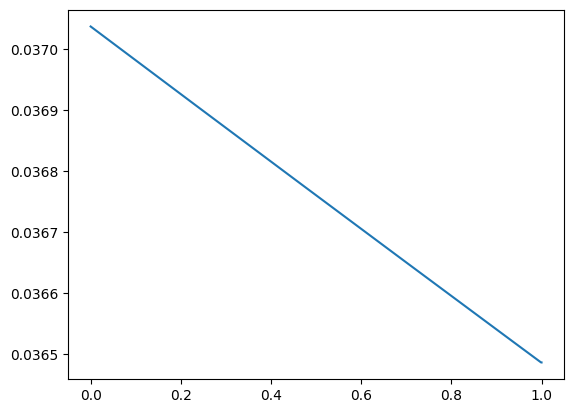

In [23]:
time = np.linspace(0, 1, len(states))
fig, ax = plt.subplots()
data = []
for i in range(len(states)):
    data.append(qt.ptrace(states[i], [0,1,2])[26,26])
ax.plot(time, data)

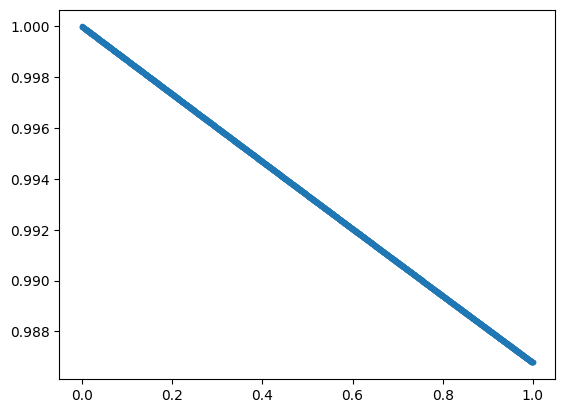

In [24]:
# plot the expectation values of the vectors and see if this result makes sense for what we want to do since this seems to work on an individual basis 
fig, ax = plt.subplots()
data = []
for i in range(len(expectation_values)):
    data.append(np.abs(expectation_values[i][len(expectation_values[0]) - 1]))
ax.plot(time, data, marker = ".")

In [ ]:
# this is not too bad will have to see who this makes sense will need to justify why the correction protocol does not seem to be that good in this case 